In [1]:
import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd
from PIL import Image
import importlib
import numpy as np
import awkward as ak
import pathlib
from IPython.display import display, HTML
import run
import config
import mucol as mu
hep.style.use(hep.style.CMS)

datafile = "BfieldStrength_TrgCenter_2026-08-14_13-20-40.parquet"
datafile = "BfieldStrength_TrgCenter_2026-08-14_13-58-01.parquet"
datafile = "BfieldStrength_TrgCenter_2026-08-14_22-41-04.parquet"
datafile = "BfieldStrength_TrgCenter_2026-08-17_15-41-18.parquet"
datafile = "BfieldStrength_TrgCenter_2026-08-17_21-12-30.parquet"
datafile = "BfieldStrength_TrgCenter_2026-08-18_16-04-53.parquet"
dataPath = str(config.nfs_scratch_flukaData) + f"/{datafile}"
print(dataPath)
data = ak.from_parquet(dataPath)

/nfs_scratch/ralharth/mucol-targetstudy/flukaData/BfieldStrength_TrgCenter_2026-08-18_16-04-53.parquet


In [5]:
data.B09.esc.PiPlus.fields

['id',
 'energy',
 'p',
 'x',
 'y',
 'z',
 'cx',
 'cy',
 'cz',
 'time',
 'gen',
 'event',
 'parentId',
 'px',
 'py',
 'pt',
 'pz',
 'eta',
 'run',
 'location']

In [2]:
rows = []

for b in config.Brange:
    B = f"B{b:02d}"
    d = data[B]

    # Number of pions in each event
    n_prod = ak.num(d.prod.PiPlus, axis=1)
    n_esc  = ak.num(d.esc.PiPlus,  axis=1)
    n_esc_gen2 = ak.num(d.esc.PiPlus[d.esc.PiPlus.gen == 2],  axis=1)
    n_esc_gen3 = ak.num(d.esc.PiPlus[d.esc.PiPlus.gen == 3],  axis=1)
    n_esc_gen3_par1 = ak.num(d.esc.PiPlus[(d.esc.PiPlus.gen == 3) & (d.esc.PiPlus.parentId == 1)],  axis=1)
    n_esc_gen4 = ak.num(d.esc.PiPlus[d.esc.PiPlus.gen == 4],  axis=1)
    n_det1 = ak.num(d.det1.PiPlus, axis=1)

    # Total number over all events
    total_prod = int(ak.sum(n_prod))
    total_esc  = int(ak.sum(n_esc))
    total_esc_gen2  = int(ak.sum(n_esc_gen2))
    total_esc_gen3  = int(ak.sum(n_esc_gen3))
    total_esc_gen3_par1  = int(ak.sum(n_esc_gen3_par1))
    total_esc_gen4  = int(ak.sum(n_esc_gen4))
    total_det1 = int(ak.sum(n_det1))

    rows.append({
        "B (T)": b,
        "Produced": total_prod,
        "Escaped": total_esc,
        "Escaped gen2": total_esc_gen2,
        "Escaped gen3": total_esc_gen3,
        "Escaped gen3 pro": total_esc_gen3_par1,
        "Escaped gen4": total_esc_gen4,
        "Detected": total_det1,
    })

df = pd.DataFrame(rows)
display(HTML(df.to_html(index=False)))

B (T),Produced,Escaped,Escaped gen2,Escaped gen3,Escaped gen3 pro,Escaped gen4,Detected
0,91355,86947,79274,7339,3837,320,27991
3,91848,88406,80501,7571,3887,327,37897
4,91319,88940,81169,7434,3827,327,43696
5,90910,89688,81741,7583,3815,355,49508
6,91409,91332,83060,7855,4081,402,54923
7,91172,92465,84205,7854,3995,384,59149
8,91737,94162,85571,8184,4129,391,63098
9,91380,95380,86591,8347,4176,420,65801
10,91275,96342,87305,8598,4310,428,67840


In [4]:
print(ak.sum(ak.num(arr)))
print(ak.sum(~ak.is_none(arr)))
print(ak.count(arr))

4
5
4


Text(0.5, 1.0, 'Pion angular distributions for 8 GeV beam [Inconel target]')

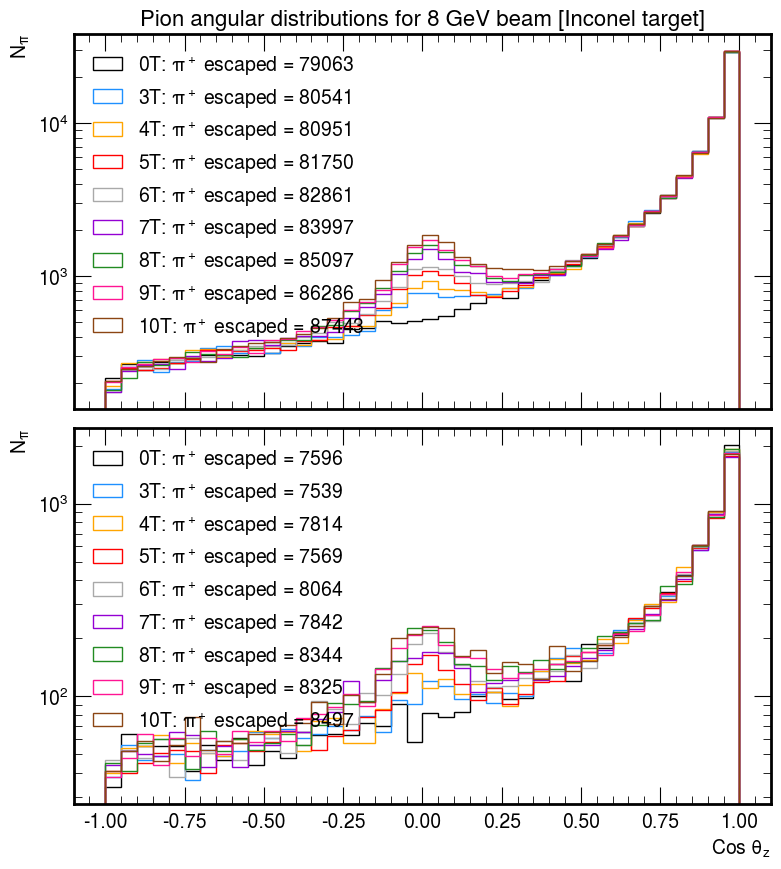

In [37]:
bins = np.linspace(-1,1,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(9, 10),
                       sharex = True,
                       gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[data[Bfield].esc.PiPlus.gen == 2]), bins,
                     f'{b}T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[data[Bfield].esc.PiPlus.gen == 2])}',
                     color = config.COLOR_MAP[Bfield])
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[data[Bfield].esc.PiPlus.gen == 3]), bins,
                     f'{b}T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[data[Bfield].esc.PiPlus.gen == 3])}',
                     color = config.COLOR_MAP[Bfield])

ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[1].set_xlabel('Cos $\\theta_z$', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[0].set_title(f'Pion angular distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

/tmp/ipykernel_3377003/14921934.py:28: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[0].set_ylim(0,100000)


Text(0.04, 0.05, 'Pions detected at the end of the solenoid')

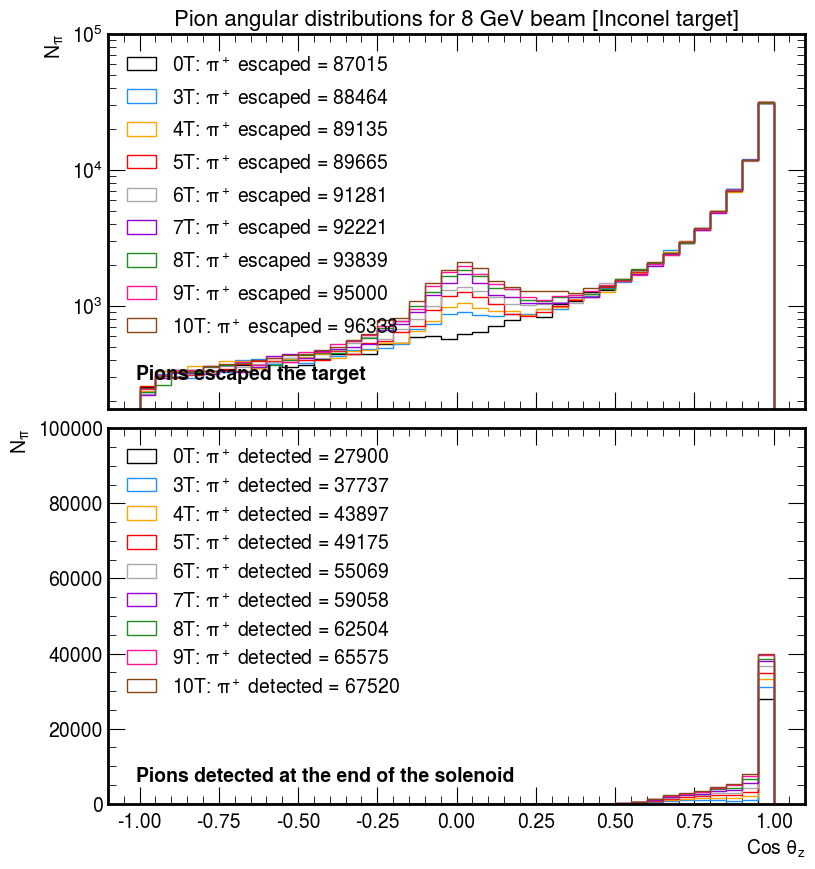

In [38]:
lower = 0
upper = 50

bins = np.linspace(-1,1,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(9, 10),
                       sharex = True,
                       gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= lower) & (data[Bfield].esc.PiPlus.p <= upper)
    det1_mom = (data[Bfield].det1.PiPlus.p >= lower) & (data[Bfield].det1.PiPlus.p <= upper)
    
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[esc_mom]), bins,
                     f'{b}T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = config.COLOR_MAP[Bfield])
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.cz[det1_mom]), bins,
                     f'{b}T: $\\pi^+$ detected = {ak.count(data[Bfield].det1.PiPlus.cz[det1_mom])}',
                     color = config.COLOR_MAP[Bfield])
ax[0].set_yscale("log")
# ax[1].set_yscale("log")
ax[-1].set_xlabel('Cos $\\theta_z$', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,100000)
ax[1].set_ylim(0,100000)

ax[0].set_title(f'Pion angular distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.04, 0.07,
    "Pions escaped the target",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)

ax[1].text(
    0.04, 0.05,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)

/tmp/ipykernel_3377003/578214956.py:22: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0,100000)


Text(0.04, 0.07, 'Pions escaped the target')

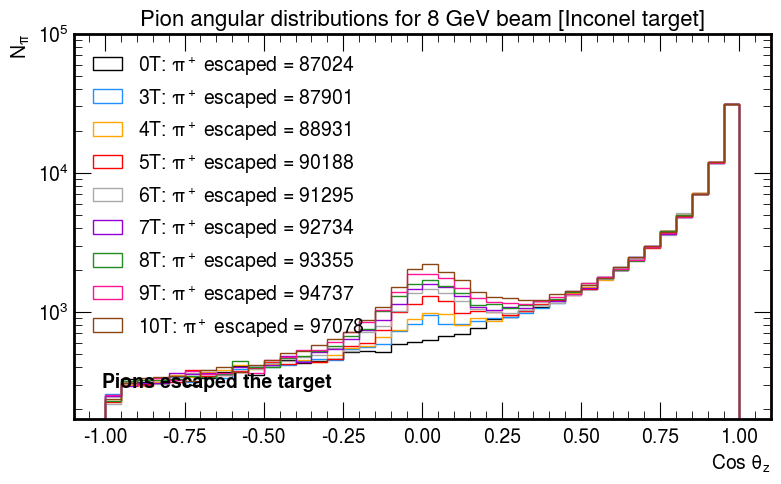

In [19]:
lower = 0
upper = 50

bins = np.linspace(-1,1,41)
fig, ax = plt.subplots(1, 1, 
                       figsize=(9, 5))
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= lower) & (data[Bfield].esc.PiPlus.p <= upper)
    det1_mom = (data[Bfield].det1.PiPlus.p >= lower) & (data[Bfield].det1.PiPlus.p <= upper)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[esc_mom]), bins,
                     f'{b}T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = config.COLOR_MAP[Bfield])

ax.set_yscale("log")
# ax[1].set_yscale("log")
ax.set_xlabel('Cos $\\theta_z$', fontsize=14)
ax.set_ylabel(r'$N_{\pi}$', fontsize=14)

ax.set_ylim(0,100000)

ax.set_title(f'Pion angular distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax.text(
    0.04, 0.07,
    "Pions escaped the target",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="bottom"
)

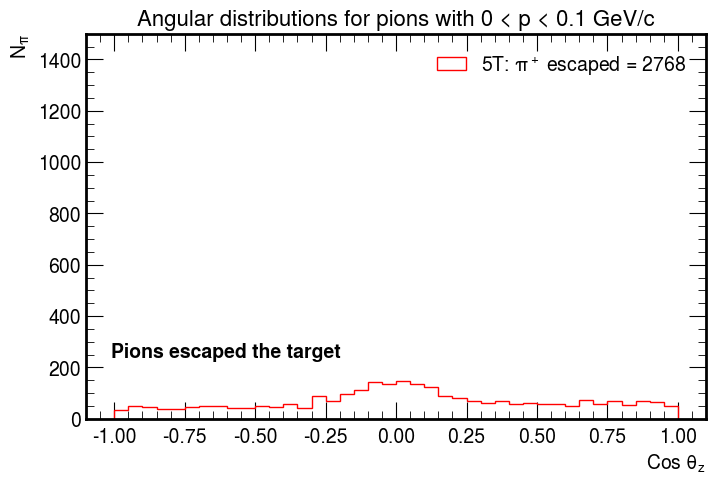

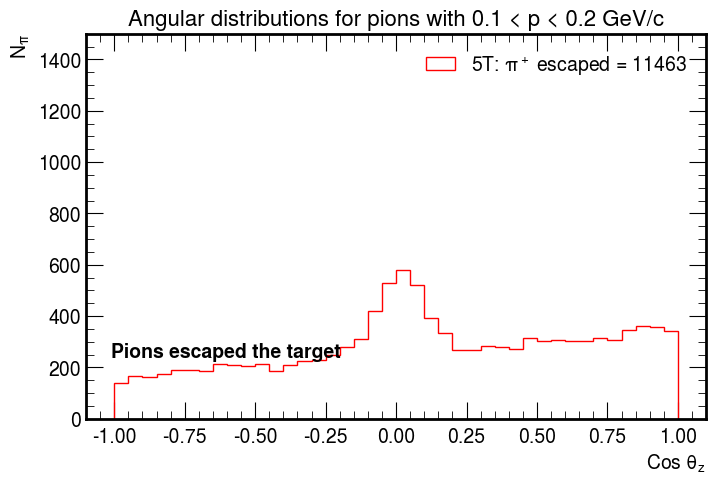

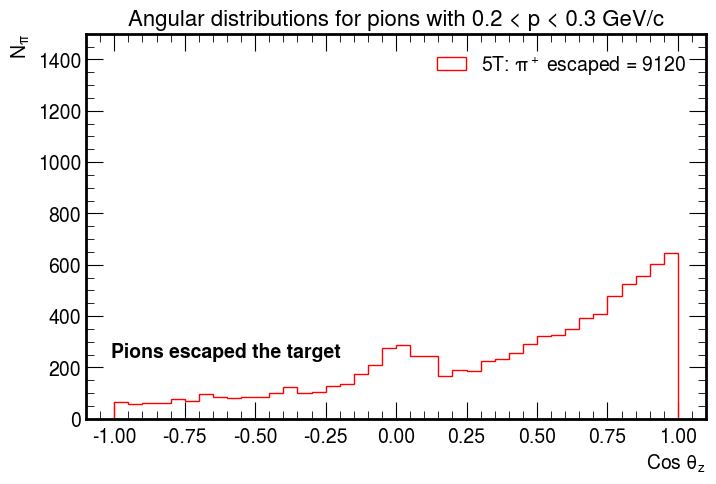

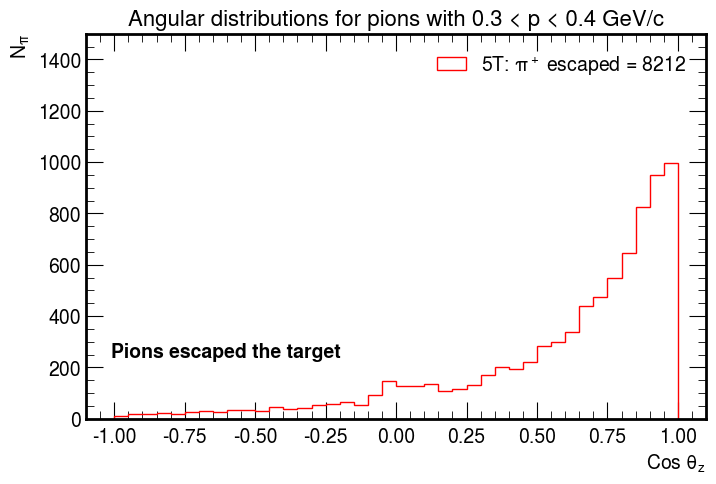

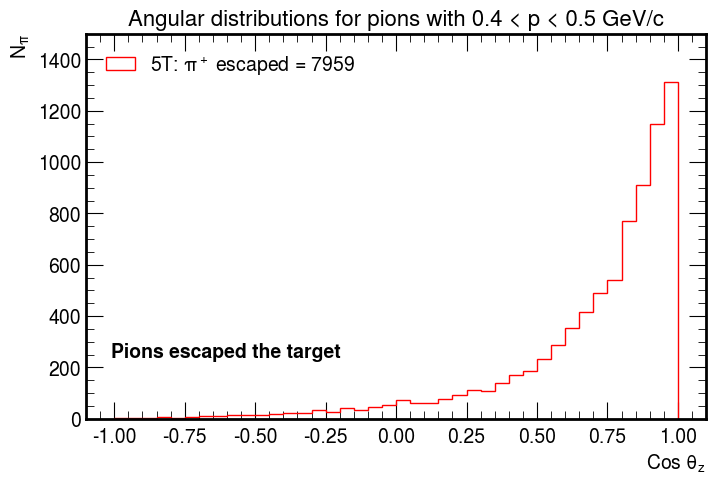

In [39]:
p_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
lower = 0.4
upper = 0.5

for i in range(len(p_range)-1):
    bins = np.linspace(-1,1,41)
    fig, ax = plt.subplots(1, 1, 
                           figsize=(8, 5))
                           # sharex = True,
                           # gridspec_kw={"hspace": 0.05})

    Bfield = f"B05"
    p_lower = p_range[i]
    p_upper = p_range[i+1]
    esc_mom = (data[Bfield].esc.PiPlus.p >= p_lower) & (data[Bfield].esc.PiPlus.p <= p_upper)
    # det1_mom = (data[Bfield].det1.PiPlus.p >= p_lower) & (data[Bfield].det1.PiPlus.p <= p_upper)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].esc.PiPlus.cz[esc_mom]), bins,
                     f'5T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = config.COLOR_MAP[Bfield])

    # ax[1].set_yscale("log")
    ax.set_xlabel('Cos $\\theta_z$', fontsize=14)
    ax.set_ylabel(r'$N_{\pi}$', fontsize=14)
    
    ax.set_ylim(0,1500)
    
    ax.set_title(f'Angular distributions for pions with {p_lower} < p < {p_upper} GeV/c', fontsize=16)
    
    ax.text(
        0.04, 0.15,
        "Pions escaped the target",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="left",
        va="bottom"
    )

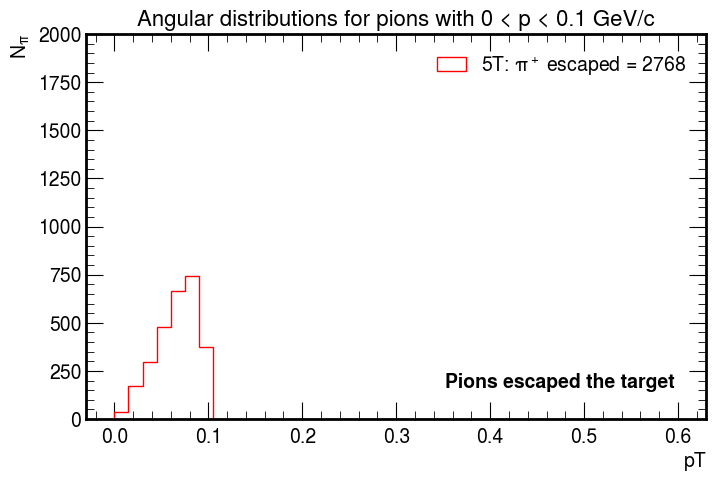

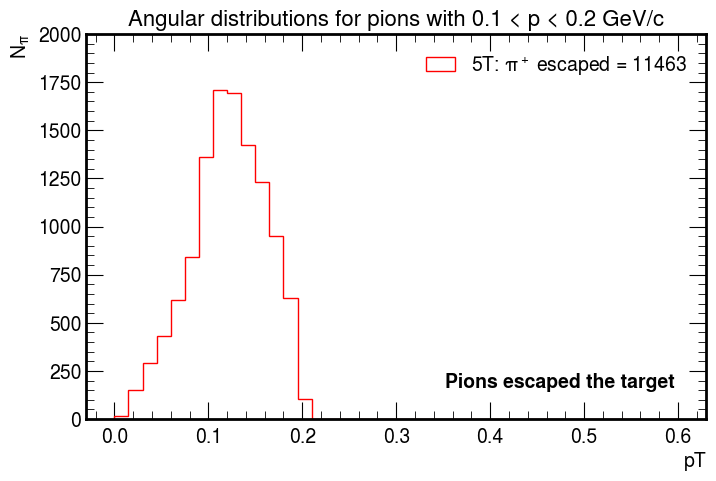

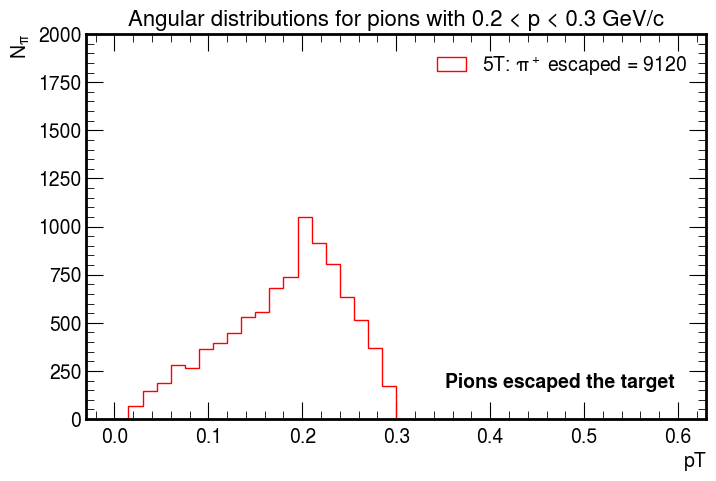

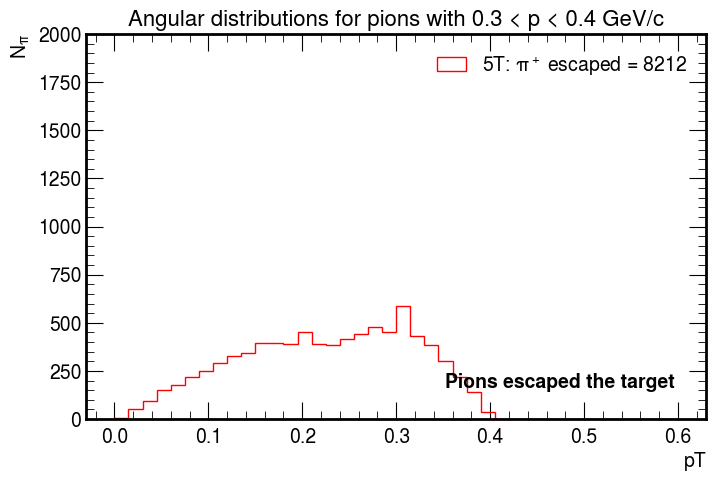

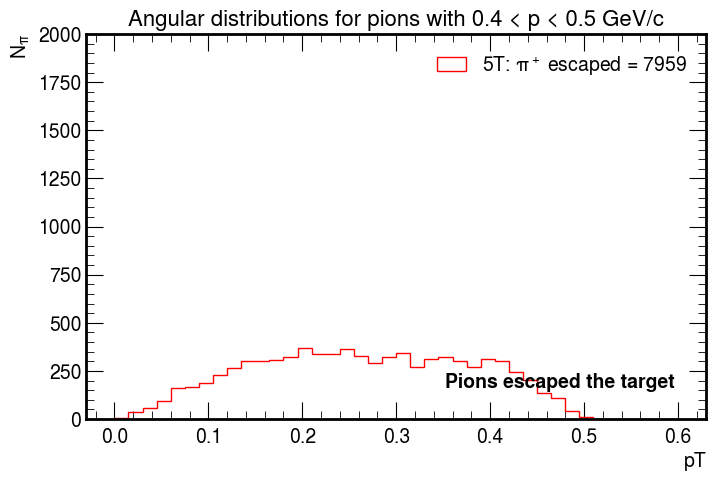

In [40]:
p_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
lower = 0.4
upper = 0.5

for i in range(len(p_range)-1):
    bins = np.linspace(0,0.6,41)
    fig, ax = plt.subplots(1, 1, 
                           figsize=(8, 5))
                           # sharex = True,
                           # gridspec_kw={"hspace": 0.05})

    Bfield = f"B05"
    p_lower = p_range[i]
    p_upper = p_range[i+1]
    esc_mom = (data[Bfield].esc.PiPlus.p >= p_lower) & (data[Bfield].esc.PiPlus.p <= p_upper)
    esc_cT = np.sqrt(data[Bfield].esc.PiPlus.cx**2 + data[Bfield].esc.PiPlus.cy**2)
    # det1_mom = (data[Bfield].det1.PiPlus.p >= p_lower) & (data[Bfield].det1.PiPlus.p <= p_upper)
    
    ax = mu.draw_hist(ax, 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_mom] * esc_cT[esc_mom]), bins,
                     f'5T: $\\pi^+$ escaped = {ak.count(data[Bfield].esc.PiPlus.cz[esc_mom])}',
                     color = config.COLOR_MAP[Bfield])

    # ax[1].set_yscale("log")
    ax.set_xlabel('pT', fontsize=14)
    ax.set_ylabel(r'$N_{\pi}$', fontsize=14)
    
    ax.set_ylim(0,2000)
    
    ax.set_title(f'Angular distributions for pions with {p_lower} < p < {p_upper} GeV/c', fontsize=16)
    
    ax.text(
        0.95, 0.07,
        "Pions escaped the target",
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        ha="right",
        va="bottom"
    )

    # buf = BytesIO()
    # plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    # plt.close(fig)

    # buf.seek(0)
    # frames.append(imageio.imread(buf))

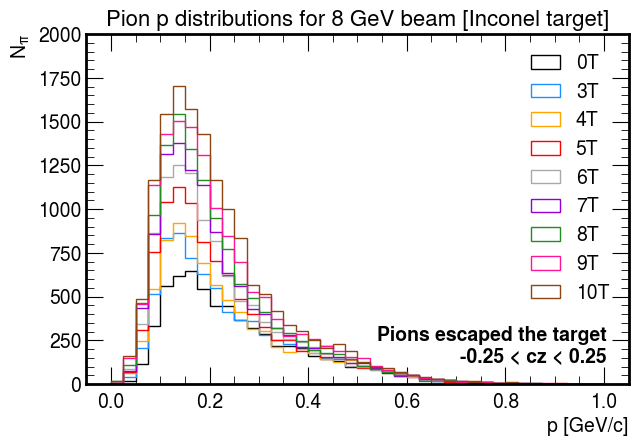

In [28]:
low_cz = -0.25
up_cz = 0.25

bins = np.linspace(0,1,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 10),)
                       # sharex = True,
                       # gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_cz = (data[Bfield].esc.PiPlus.cz >= low_cz) & (data[Bfield].esc.PiPlus.cz <= up_cz)
    det1_cz = (data[Bfield].det1.PiPlus.cz >= low_cz) & (data[Bfield].det1.PiPlus.cz <= up_cz)
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p[det1_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
# ax[1].set_yscale("log")
ax[0].set_xlabel('p [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,2000)
ax[1].set_ylim(0,35000)

ax[0].set_title(f'Pion p distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.96, 0.05,
    "Pions escaped the target\n-0.25 < cz < 0.25",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

ax[1].text(
    0.96, 0.05,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

fig.delaxes(ax[1])

Text(0.04, 0.95, 'Pions detected at the end of the solenoid')

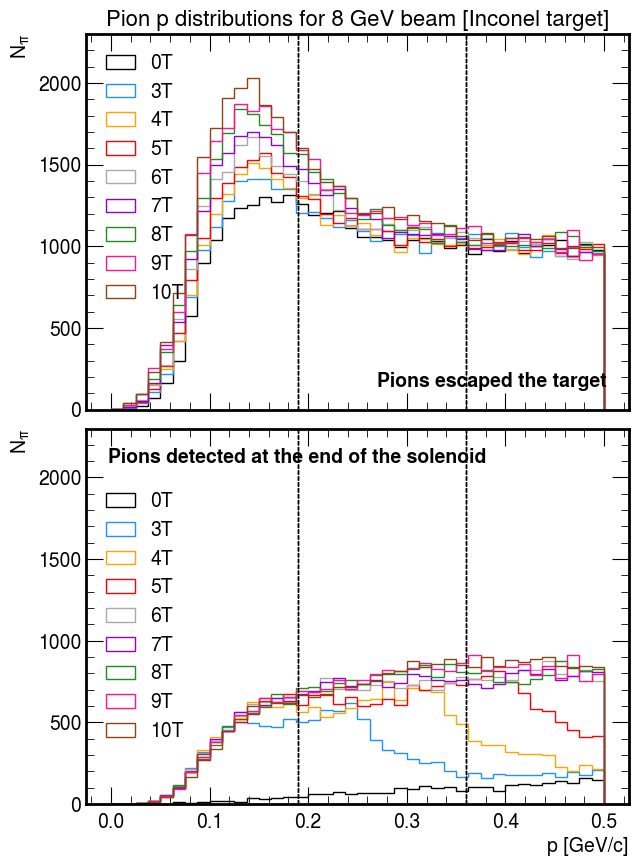

In [45]:
bins = np.linspace(0,0.5,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 10),
                       sharex = True,
                       gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    ax[0].axvline(0.19, color="black", linestyle="--", linewidth=0.8)
    ax[0].axvline(0.36, color="black", linestyle="--", linewidth=0.8)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    ax[1].axvline(0.19, color="black", linestyle="--", linewidth=0.8)
    ax[1].axvline(0.36, color="black", linestyle="--", linewidth=0.8)
# ax[1].set_yscale("log")
ax[-1].set_xlabel('p [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,2300)
ax[1].set_ylim(0,2300)

ax[0].set_title(f'Pion p distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.96, 0.05,
    "Pions escaped the target",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

ax[1].text(
    0.04, 0.95,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="top"
)

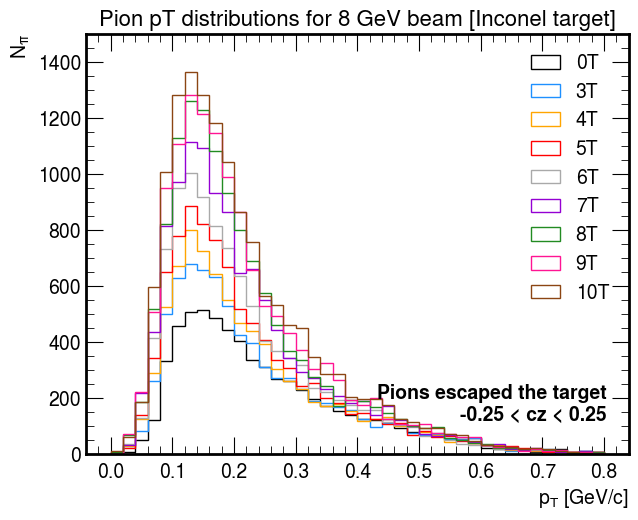

In [42]:
bins = np.linspace(0,0.8,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 12),)
                       # sharex = True,
                       # gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_cT = np.sqrt(data[Bfield].esc.PiPlus.cx**2 + data[Bfield].esc.PiPlus.cy**2)
    
    esc_cz = (data[Bfield].esc.PiPlus.cz >= low_cz) & (data[Bfield].esc.PiPlus.cz <= up_cz)
    det1_cz = (data[Bfield].det1.PiPlus.cz >= low_cz) & (data[Bfield].det1.PiPlus.cz <= up_cz)
    
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_cz] * esc_cT[esc_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    det1_cT = np.sqrt(data[Bfield].det1.PiPlus.cx**2 + data[Bfield].det1.PiPlus.cy**2)
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p[det1_cz] * det1_cT[det1_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
# ax[1].set_yscale("log")
ax[0].set_xlabel('$p_T$ [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,1500)
ax[1].set_ylim(0,12500)

ax[0].set_title(f'Pion pT distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.96, 0.07,
    "Pions escaped the target\n-0.25 < cz < 0.25",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

ax[1].text(
    0.96, 0.15,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

fig.delaxes(ax[1])

Text(0.04, 0.93, 'Pions detected at the end of the solenoid')

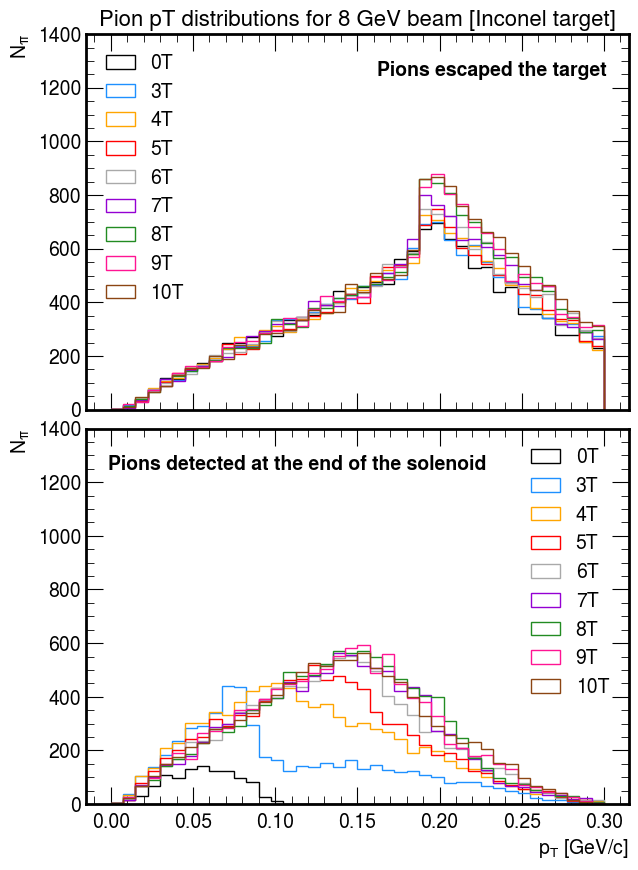

In [43]:
bins = np.linspace(0,0.3,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 10),
                       sharex = True,
                       gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    esc_cT = np.sqrt(data[Bfield].esc.PiPlus.cx**2 + data[Bfield].esc.PiPlus.cy**2)
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_mom] * esc_cT[esc_mom]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    det1_cT = np.sqrt(data[Bfield].det1.PiPlus.cx**2 + data[Bfield].det1.PiPlus.cy**2)
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p[det1_mom] * det1_cT[det1_mom]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
# ax[1].set_yscale("log")
ax[-1].set_xlabel('$p_T$ [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,1400)
ax[1].set_ylim(0,1400)

ax[0].set_title(f'Pion pT distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.96, 0.93,
    "Pions escaped the target",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="top"
)

ax[1].text(
    0.04, 0.93,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="top"
)

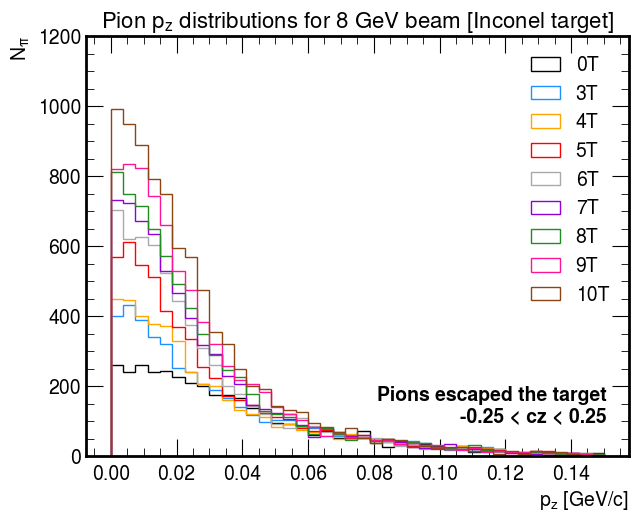

In [33]:
bins = np.linspace(0,0.15,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 12),)
                       # sharex = True,
                       # gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_cz = (data[Bfield].esc.PiPlus.cz >= low_cz) & (data[Bfield].esc.PiPlus.cz <= up_cz)
    det1_cz = (data[Bfield].det1.PiPlus.cz >= low_cz) & (data[Bfield].det1.PiPlus.cz <= up_cz)
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_cz] * data[Bfield].esc.PiPlus.cz[esc_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p[det1_cz] * data[Bfield].det1.PiPlus.cz[det1_cz]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
# ax[1].set_yscale("log")
ax[0].set_xlabel('$p_z$ [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,1200)
ax[1].set_ylim(0,2000)

ax[0].set_title(rf'Pion $p_z$ distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.96, 0.07,
    "Pions escaped the target\n-0.25 < cz < 0.25",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

ax[1].text(
    0.96, 0.2,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="right",
    va="bottom"
)

fig.delaxes(ax[1])

Text(0.04, 0.93, 'Pions detected at the end of the solenoid')

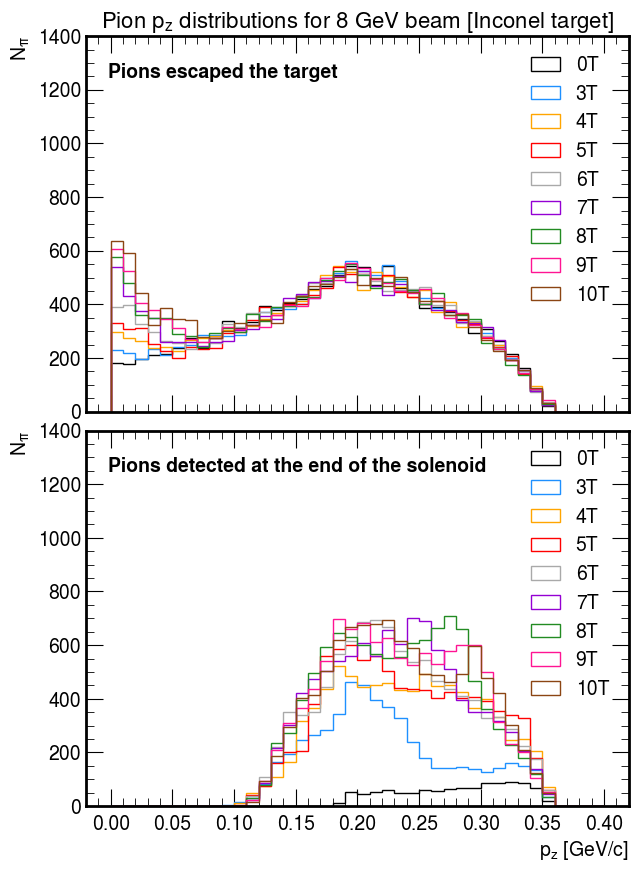

In [44]:
bins = np.linspace(0,0.4,41)
fig, ax = plt.subplots(2, 1, 
                       figsize=(7, 10),
                       sharex = True,
                       gridspec_kw={"hspace": 0.05})
for b in config.Brange:
    Bfield = f"B{b:02d}"
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    ax[0] = mu.draw_hist(ax[0], 
                     ak.flatten(data[Bfield].esc.PiPlus.p[esc_mom] * data[Bfield].esc.PiPlus.cz[esc_mom]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    ax[1] = mu.draw_hist(ax[1], 
                     ak.flatten(data[Bfield].det1.PiPlus.p[det1_mom] * data[Bfield].det1.PiPlus.cz[det1_mom]), bins,
                     f'{b}T',
                     color = config.COLOR_MAP[Bfield])
# ax[1].set_yscale("log")
ax[-1].set_xlabel('$p_z$ [GeV/c]', fontsize=14)
ax[0].set_ylabel(r'$N_{\pi}$', fontsize=14)
ax[1].set_ylabel(r'$N_{\pi}$', fontsize=14)

ax[0].set_ylim(0,1400)
ax[1].set_ylim(0,1400)

ax[0].set_title(rf'Pion $p_z$ distributions for {data.B09.metadata.beamEnergy} GeV beam [{data.B09.metadata.target.material} target]', fontsize=16)

ax[0].text(
    0.04, 0.93,
    "Pions escaped the target",
    transform=ax[0].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="top"
)

ax[1].text(
    0.04, 0.93,
    "Pions detected at the end of the solenoid",
    transform=ax[1].transAxes,
    fontsize=14,
    fontweight="bold",
    ha="left",
    va="top"
)

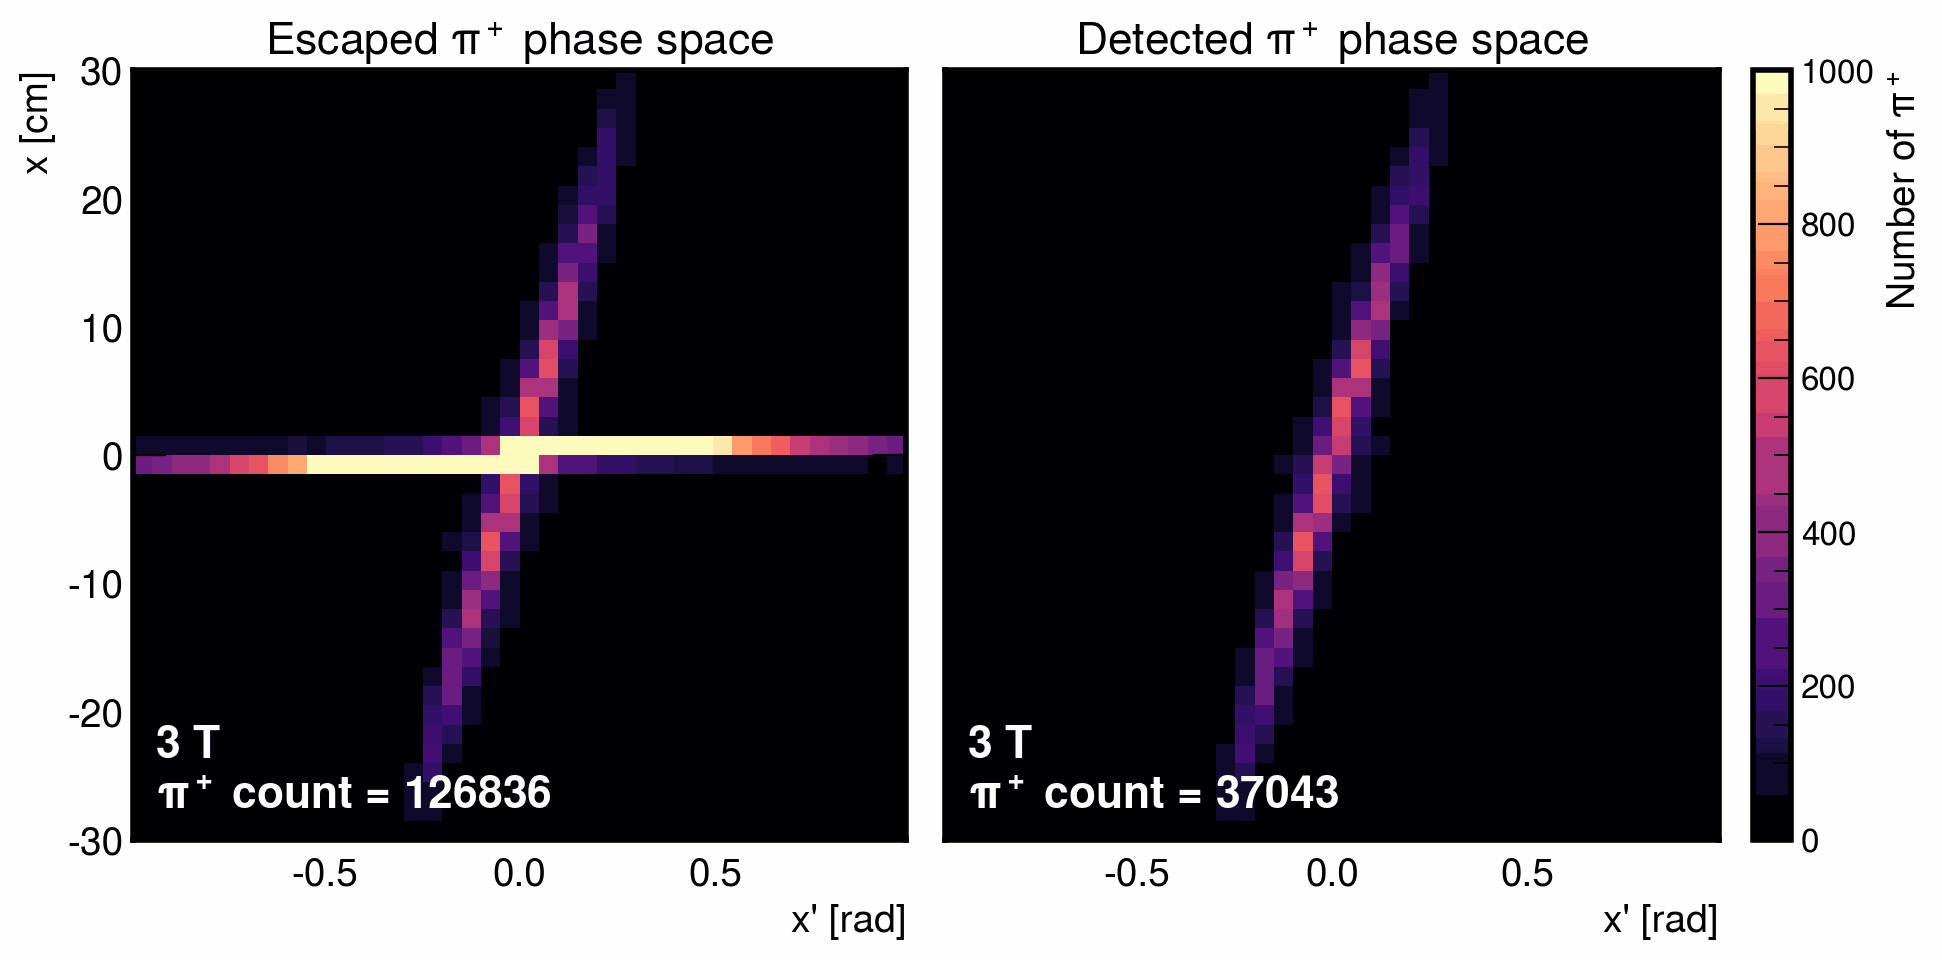

In [36]:
import imageio.v2 as imageio
from io import BytesIO
from IPython.display import Image, display

frames = []

for b in run.Brange:
    xbins = np.linspace(-0.99,0.99,41)
    ybins = np.linspace(-30,30,41)
    bins = [xbins, ybins]
    fig, ax = plt.subplots(1, 2, 
                           figsize=(11, 5),
                           sharey = True,
                           gridspec_kw={"wspace": 0.05})
    Bfield = f"B{b:02d}"
    esc_px = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cx
    esc_pz = data[Bfield].esc.PiPlus.p * data[Bfield].esc.PiPlus.cz
    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(esc_px/esc_pz), ak.flatten(data[Bfield].esc.PiPlus.x),
                               bins,
                               vmax=800)
    det1_px = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cx
    det1_pz = data[Bfield].det1.PiPlus.p * data[Bfield].det1.PiPlus.cz
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(det1_px/det1_pz), ak.flatten(data[Bfield].det1.PiPlus.x),
                               bins,
                               vmax=800)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_ylabel(r'x [cm]', fontsize=14)
    ax[0].set_title(rf'Escaped $\pi^+$ phase space', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ phase space', fontsize=16)

    ax[0].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].esc.PiPlus))}",
        transform=ax[0].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
    
    ax[1].text(
        0.03, 0.03,
        f"{b} T\n" + rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].det1.PiPlus))}",
        transform=ax[1].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    # plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=200, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_ps.gif",
    frames,
    duration=700,
    loop=0,
)

display(Image(filename="piplus_ps.gif"))

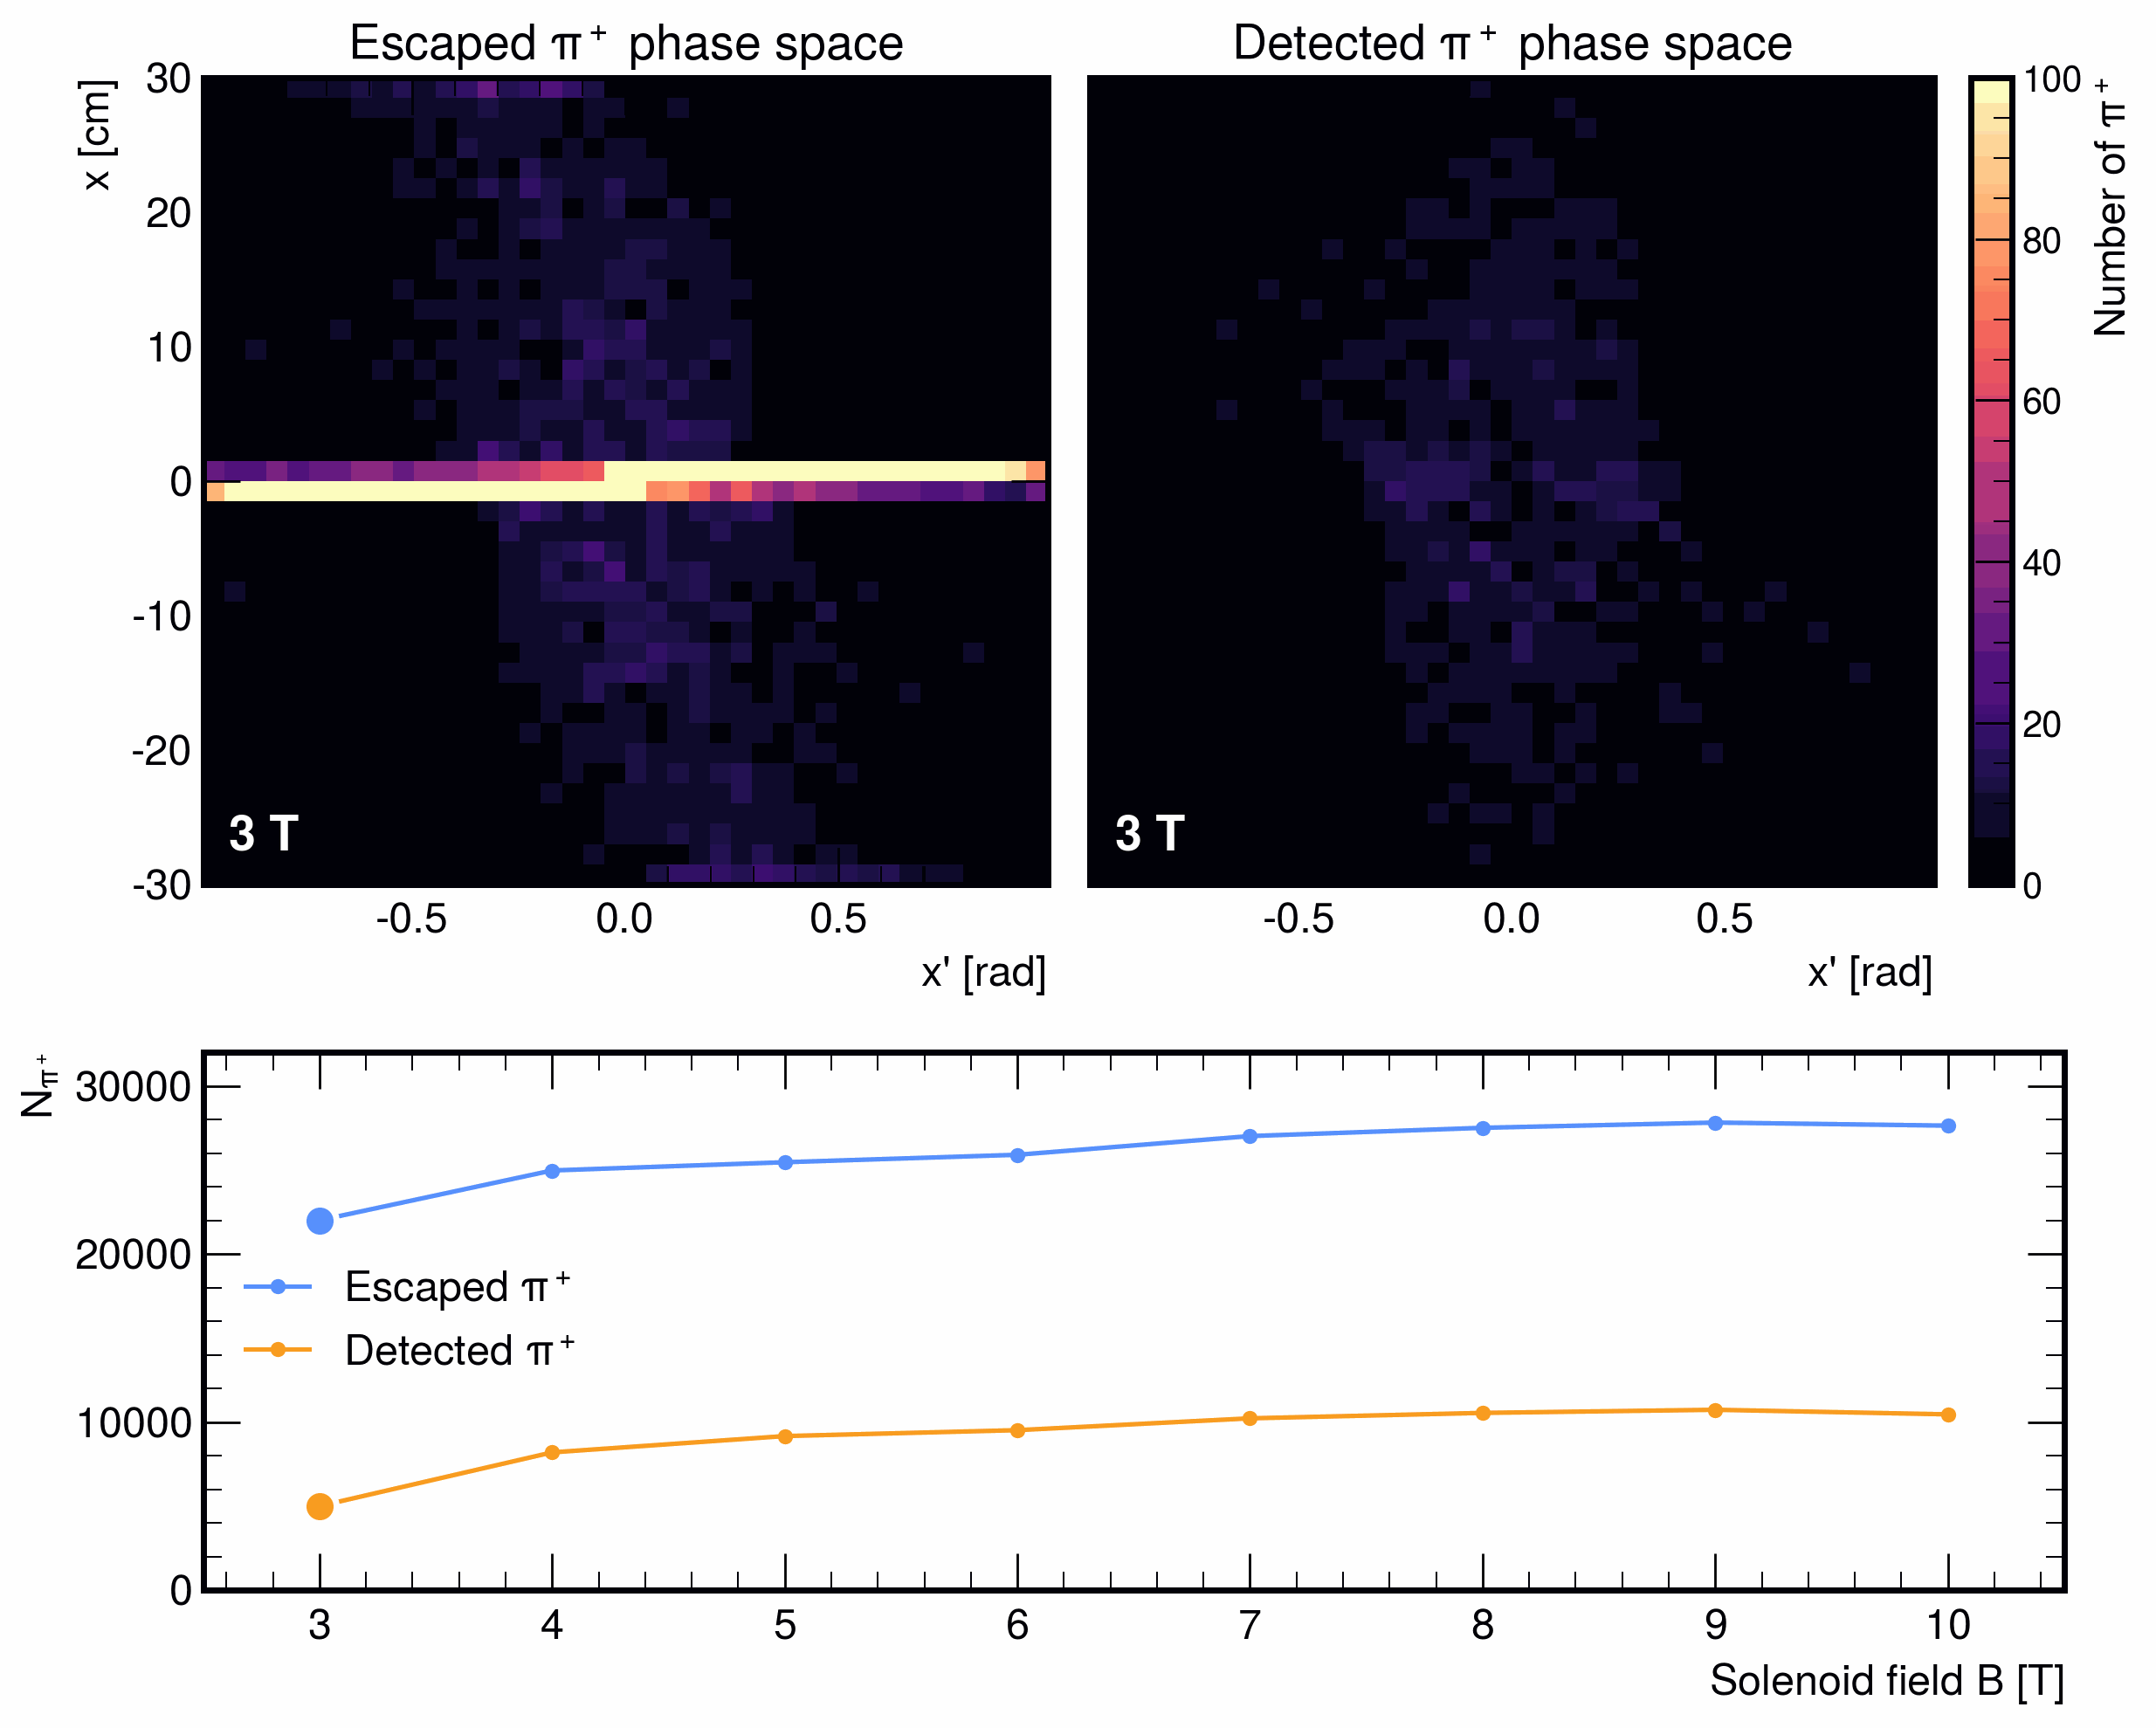

In [60]:
frames = []

B_values = []
esc_counts = []
det_counts = []

for b in run.Brange:
    Bfield = f"B{b:02d}"
    B_values.append(b)

    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    esc_counts.append(ak.sum(ak.num(data[Bfield].esc.PiPlus[esc_mom])))
    det_counts.append(ak.sum(ak.num(data[Bfield].det1.PiPlus[det1_mom])))

for i, b in enumerate(run.Brange):
    Bfield = f"B{b:02d}"
    xbins = np.linspace(-0.99,0.99,41)
    ybins = np.linspace(-30,30,41)
    bins = [xbins, ybins]

    fig = plt.figure(figsize=(11, 9))
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=[6,4],
        hspace=0.25,
        wspace=0.05
    )

    ax0 = fig.add_subplot(gs[0,0])
    ax1 = fig.add_subplot(gs[0,1], sharey=ax0)
    
    ax = [ax0, ax1]
    
    ax_count = fig.add_subplot(gs[1,:])
    
    # fig, ax = plt.subplots(1, 2, 
    #                        figsize=(11, 5),
    #                        sharey = True,
    #                        gridspec_kw={"wspace": 0.05})
    esc_mom = (data[Bfield].esc.PiPlus.p >= 0.19) & (data[Bfield].esc.PiPlus.p <= 0.36)
    det1_mom = (data[Bfield].det1.PiPlus.p >= 0.19) & (data[Bfield].det1.PiPlus.p <= 0.36)
    
    esc_px = data[Bfield].esc.PiPlus.p[esc_mom] * data[Bfield].esc.PiPlus.cx[esc_mom]
    esc_pz = data[Bfield].esc.PiPlus.p[esc_mom] * data[Bfield].esc.PiPlus.cz[esc_mom]
    
    ax[0], h0 = mu.draw_hist2d(ax[0], 
                               ak.flatten(esc_px/esc_pz), ak.flatten(data[Bfield].esc.PiPlus.x[esc_mom]),
                               bins,
                               vmax=100)
    det1_px = data[Bfield].det1.PiPlus.p[det1_mom] * data[Bfield].det1.PiPlus.cx[det1_mom]
    det1_pz = data[Bfield].det1.PiPlus.p[det1_mom] * data[Bfield].det1.PiPlus.cz[det1_mom]
    ax[1], h1 = mu.draw_hist2d(ax[1], 
                               ak.flatten(det1_px/det1_pz), ak.flatten(data[Bfield].det1.PiPlus.x[det1_mom]),
                               bins,
                               vmax=100)

    cbar = fig.colorbar(
        h1[3],      # QuadMesh from the last hist2d call
        ax=ax,      # both subplots
        location="right",
        pad=0.02,
        fraction=0.05,
    )
    
    cbar.set_label(r"Number of $\pi^+$", fontsize=14)
    cbar.ax.tick_params(labelsize=12)

    ax[1].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_xlabel('x\' [rad]', fontsize=14)
    ax[0].set_ylabel(r'x [cm]', fontsize=14)
    ax[1].tick_params(axis='y', labelleft=False)
    ax[0].set_title(rf'Escaped $\pi^+$ phase space', fontsize=16)
    ax[1].set_title(rf'Detected $\pi^+$ phase space', fontsize=16)

    ax[0].text(
        0.03, 0.03,
        f"{b} T", #+ rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].esc.PiPlus))}",
        transform=ax[0].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
    
    ax[1].text(
        0.03, 0.03,
        f"{b} T", #+ rf"$\pi^+$ count = {ak.sum(ak.num(data[Bfield].det1.PiPlus))}",
        transform=ax[1].transAxes,
        color="white",
        fontsize=16,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

    # --------------------
    # full count history
    # --------------------
    ax_count.plot(
        B_values,
        esc_counts,
        "-o",
        markersize=4,
        label=r"Escaped $\pi^+$"
    )

    ax_count.plot(
        B_values,
        det_counts,
        "-o",
        markersize=4,
        label=r"Detected $\pi^+$"
    )


    # highlighted current point
    ax_count.scatter(
        b,
        esc_counts[i],
        s=120,
        edgecolor="white",
        linewidth=2,
        zorder=5
    )

    ax_count.scatter(
        b,
        det_counts[i],
        s=120,
        edgecolor="white",
        linewidth=2,
        zorder=5
    )


    # ax_count.set_xlim(min(B_values), max(B_values))
    ax_count.set_xlim(2.5, 10.5)
    ax_count.set_ylim(
        0,
        max(det_counts + esc_counts)*1.15
    )

    ax_count.set_xlabel("Solenoid field $B$ [T]", fontsize=14)
    ax_count.set_ylabel(r"$N_{\pi^+}$", fontsize=14)
    ax_count.tick_params(axis='both', labelsize=14)
    ax_count.legend(fontsize=14, loc="center left")

    # plt.show()

    buf = BytesIO()
    plt.savefig(buf, format="png", dpi=250, bbox_inches="tight")
    plt.close(fig)

    buf.seek(0)
    frames.append(imageio.imread(buf))

imageio.mimsave(
    "piplus_ps.gif",
    frames,
    duration=800,
    loop=0,
)

display(Image(filename="piplus_ps.gif"))